## Synthetic Medical Diagnosis Record Generation Using CTGAN

## Notebook 1: Exploratory Data Analysis and Data Preprocessing

### Project Domain
Healthcare

### Objective
To explore, clean, and preprocess the healthcare dataset before training a CTGAN model for synthetic medical diagnosis record generation.

### Dataset
Diabetes Prediction Dataset

#EDA & Data Preprocessing



In [ ]:
# Install required libraries

!pip install sdv
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 3.7 MB/s eta 0:00:00


In [ ]:
#Import lib.
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")

In [ ]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 100000
Columns : 9


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [ ]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [ ]:
df.duplicated().sum()

np.int64(3854)

In [ ]:
df = df.drop_duplicates()

print(df.shape)

(96146, 9)


In [ ]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("--------------------------------")

gender
['Female' 'Male' 'Other']
--------------------------------
age
[80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
--------------------------------
hypertension
[0 1]
--------------------------------
heart_disease
[1 0]
--------------------------------
smoking_history
['never' 'No Info' 'current' 'former' 'ever' 'not current']
--------------------------------
bmi
[25.19 27.32 23.45 ... 59.42 44.39 60.52]
-------------------------

#EDA

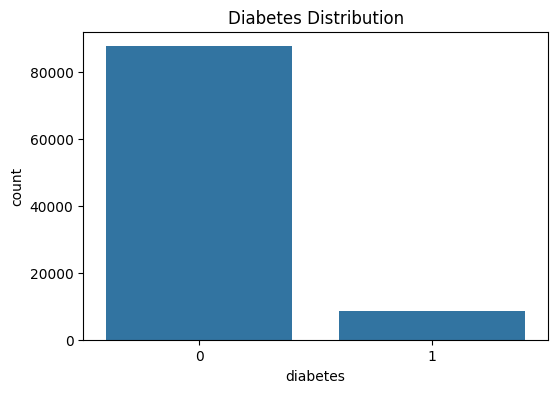

In [ ]:
#Target Variable Count
plt.figure(figsize=(6,4))

sns.countplot(x='diabetes', data=df)

plt.title("Diabetes Distribution")

plt.show()

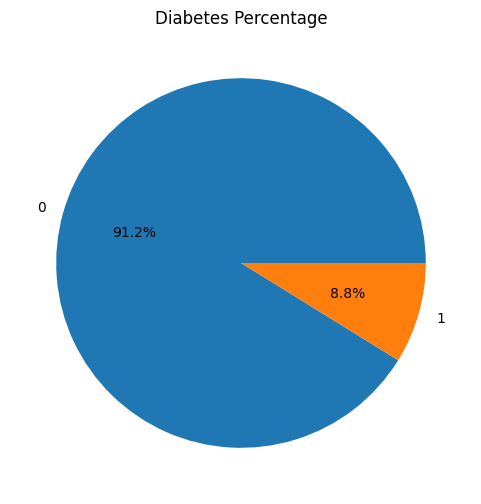

In [ ]:
df['diabetes'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(6,6)
)

plt.title("Diabetes Percentage")

plt.ylabel("")

plt.show()

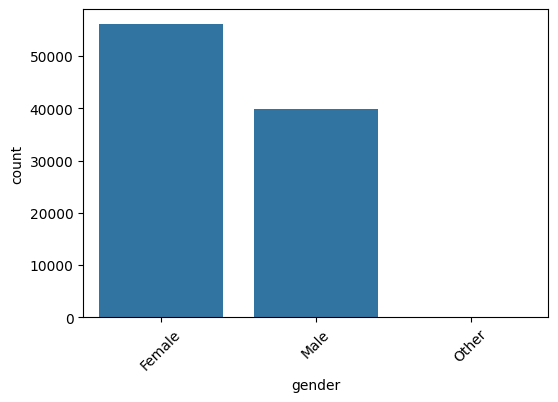

In [ ]:
#Gender Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='gender', data=df)

plt.xticks(rotation=45)

plt.show()

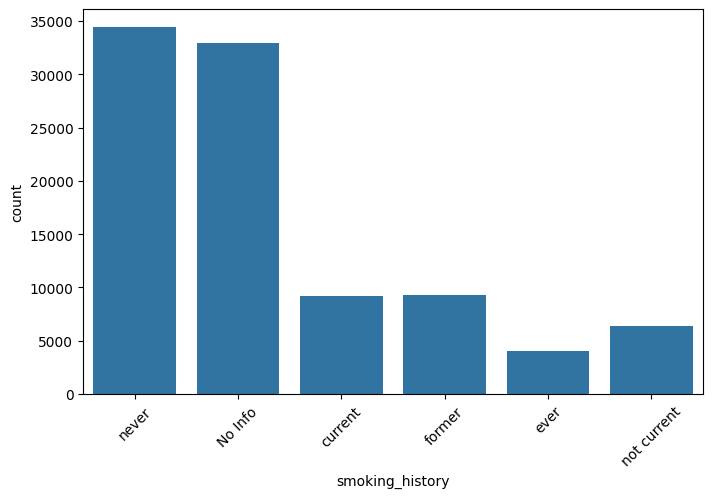

In [ ]:
#Smoking History
plt.figure(figsize=(8,5))

sns.countplot(x='smoking_history', data=df)

plt.xticks(rotation=45)

plt.show()

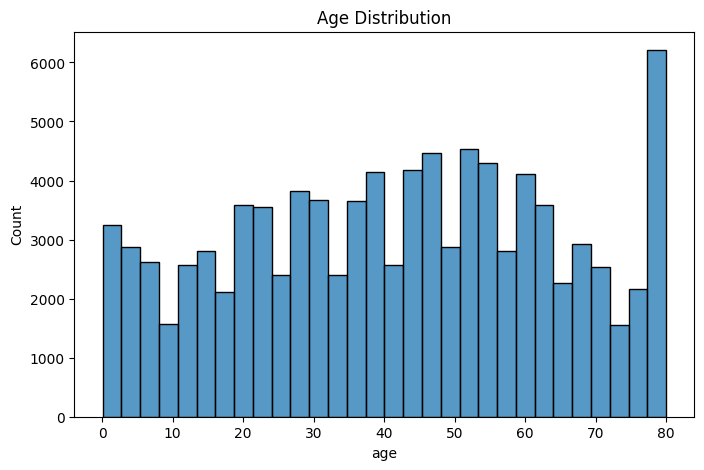

In [ ]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=30)

plt.title("Age Distribution")

plt.show()

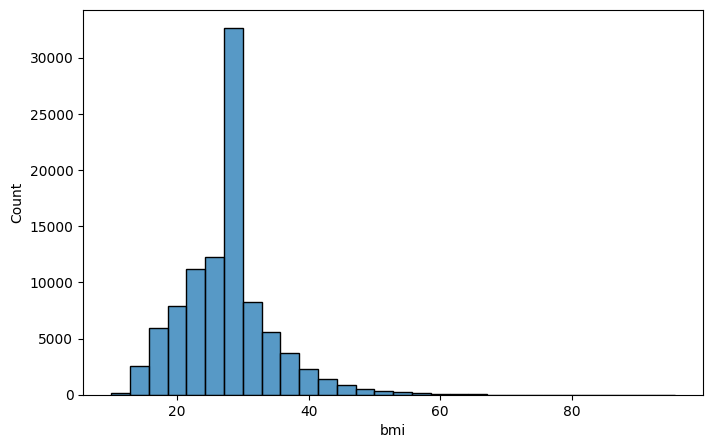

In [ ]:
#BMI Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['bmi'], bins=30)

plt.show()

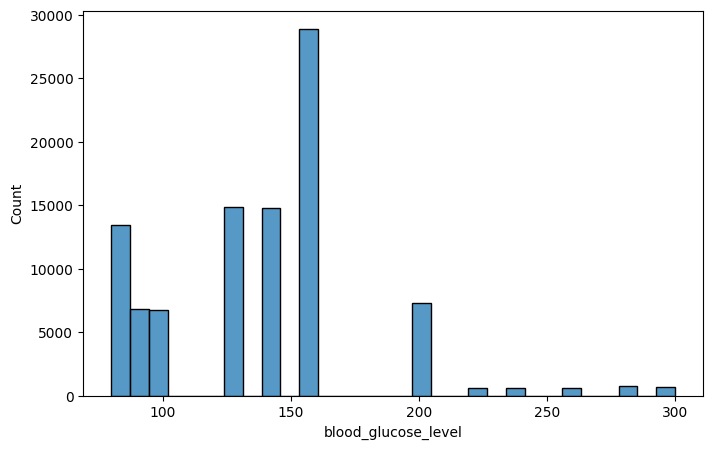

In [ ]:
#Blood Glucose Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['blood_glucose_level'], bins=30)

plt.show()

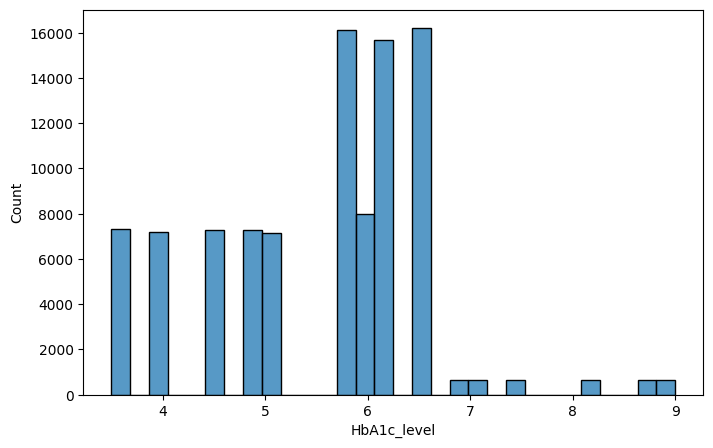

In [ ]:
#HbA1c Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['HbA1c_level'], bins=30)

plt.show()

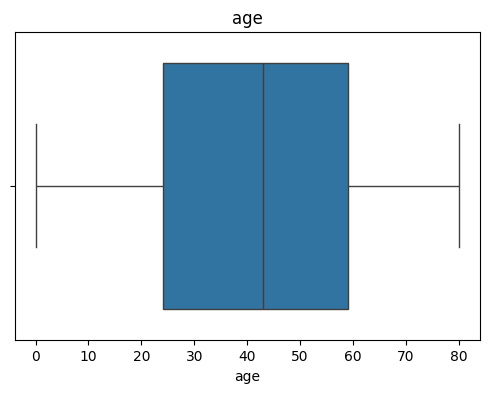

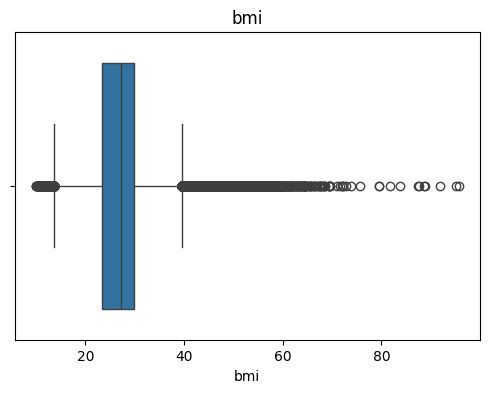

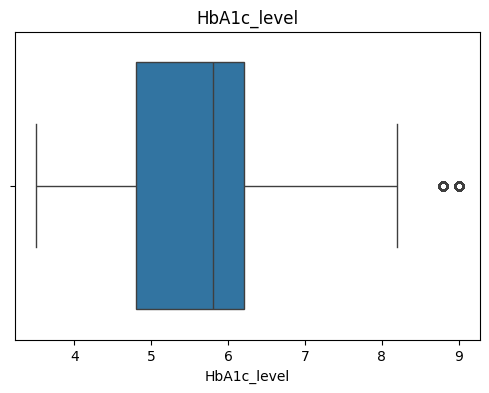

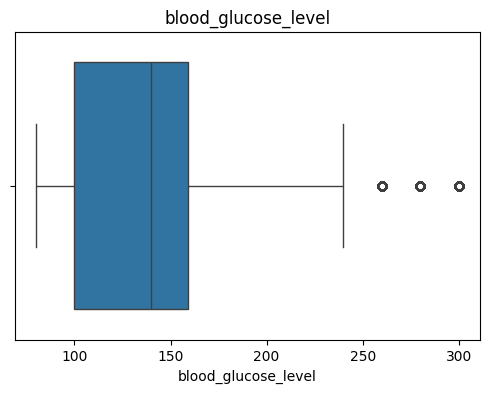

In [ ]:
#Boxplots
numerical_columns = ['age','bmi','HbA1c_level','blood_glucose_level']
for col in numerical_columns:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [ ]:
#Encode Categorical Columns
encoder = LabelEncoder()

df['gender'] = encoder.fit_transform(df['gender'])

df['smoking_history'] = encoder.fit_transform(df['smoking_history'])

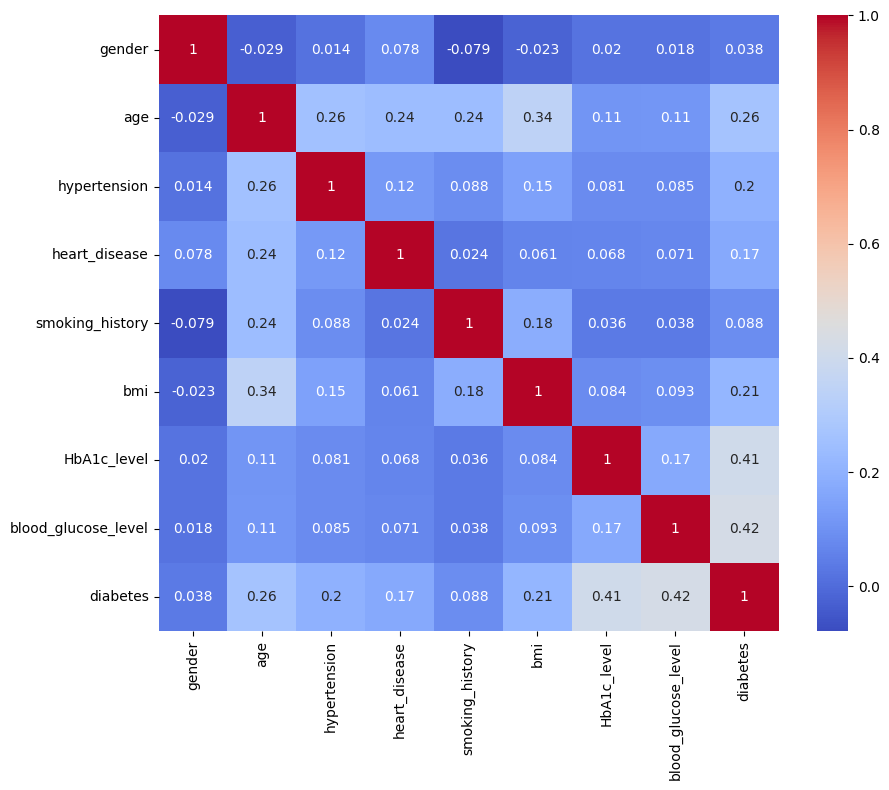

In [ ]:
#Correlation Heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

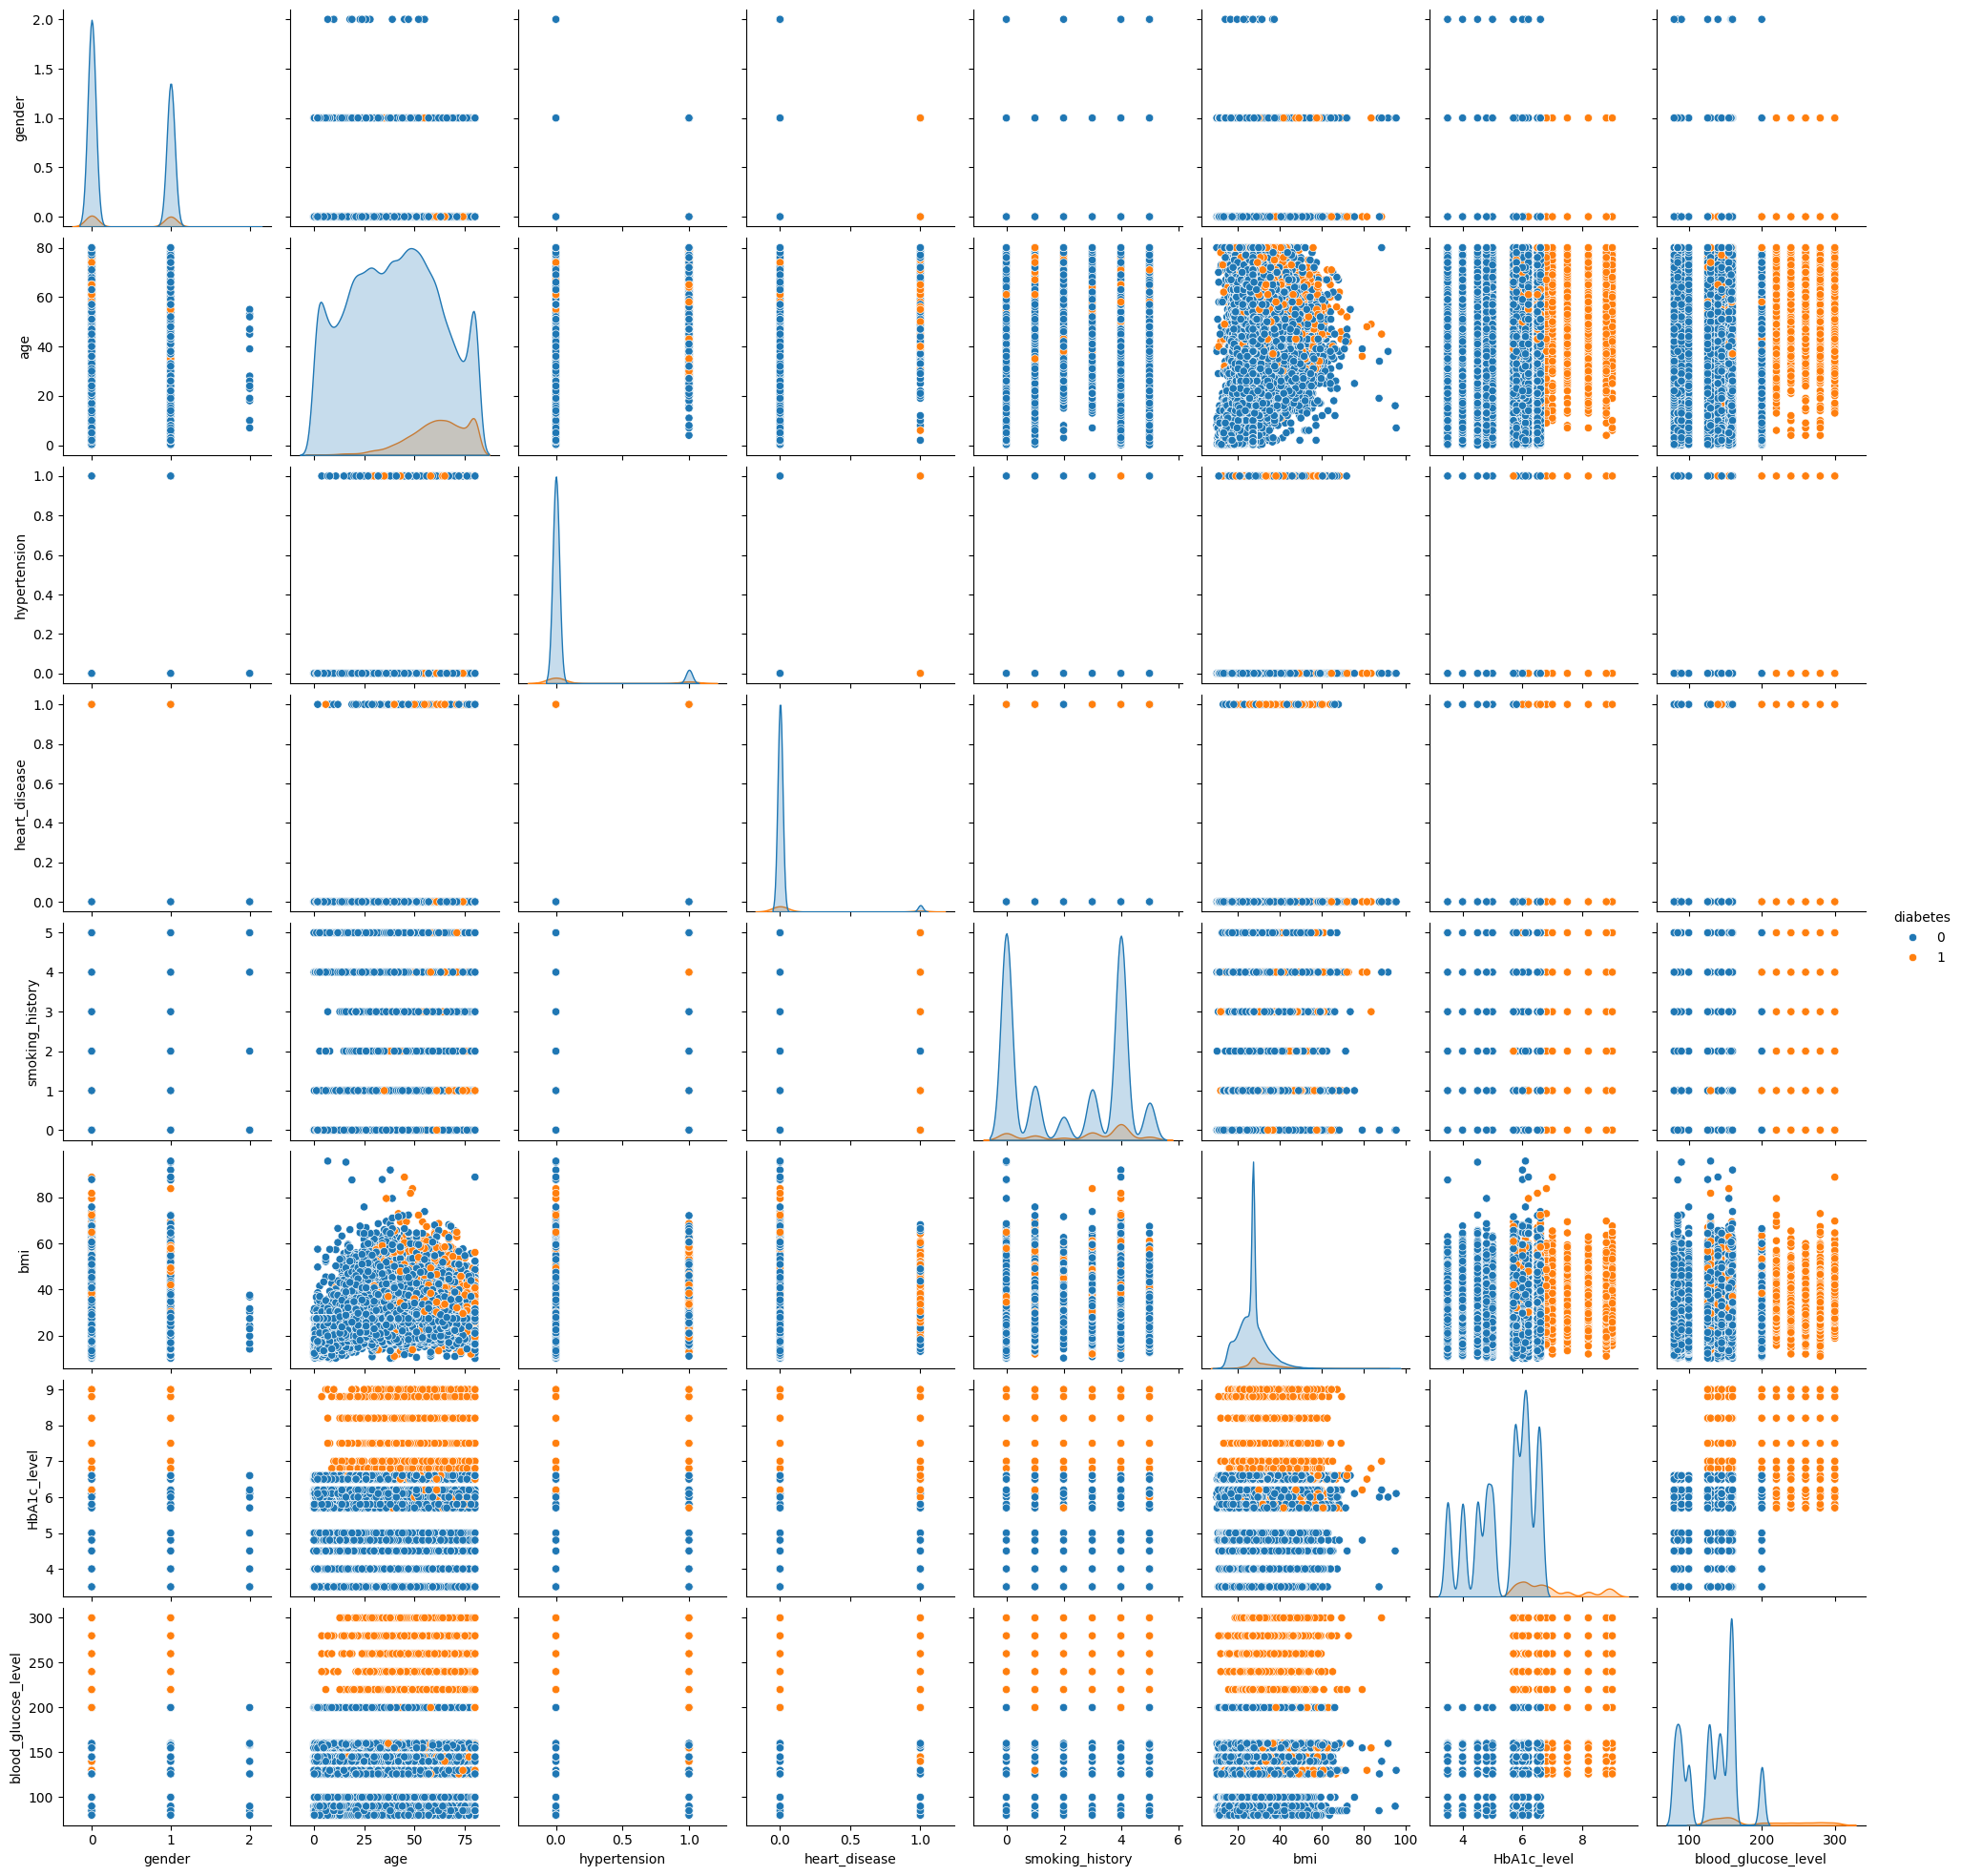

In [ ]:
#Pairplot
sns.pairplot(df,hue="diabetes")
plt.show()

In [ ]:
#Feature Scaling
scaler = StandardScaler()
columns = ['age','bmi','HbA1c_level','blood_glucose_level']
df[columns] = scaler.fit_transform(df[columns])

In [ ]:
#Save Clean Dataset
df.to_csv("clean_diabetes_dataset.csv",index=False)

#CTGAN Training & Synthetic Medical Data Generation

In [ ]:
!pip install sdv


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.1/90.1 kB 6.6 MB/s eta 0:00:00


In [ ]:
#Import Libraries
import pandas as pd
import numpy as np

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

import joblib

In [ ]:
df = pd.read_csv("/content/clean_diabetes_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0.0,1.0,4.0,-0.314947,0.994563,0.043554,0.0
1,0,0.543372,0.0,0.0,0.0,-0.000216,0.994563,-1.423096,0.0
2,1,-0.614096,0.0,0.0,4.0,-0.000216,0.155970,0.483549,0.0
3,0,-0.257952,0.0,0.0,1.0,-0.572051,-0.496269,0.410216,0.0
4,1,1.522768,1.0,1.0,1.0,-1.061141,-0.682623,0.410216,0.0


In [ ]:
print(df.shape)

(58665, 9)


In [ ]:
#Create Metadata
metadata = SingleTableMetadata()

metadata.detect_from_dataframe(df)

In [ ]:
#View Metadata
metadata

{
    "METADATA_SPEC_VERSION": "SINGLE_TABLE_V1",
    "columns": {
        "gender": {
            "sdtype": "categorical"
        },
        "age": {
            "sdtype": "numerical"
        },
        "hypertension": {
            "sdtype": "categorical"
        },
        "heart_disease": {
            "sdtype": "categorical"
        },
        "smoking_history": {
            "sdtype": "categorical"
        },
        "bmi": {
            "sdtype": "numerical"
        },
        "HbA1c_level": {
            "sdtype": "numerical"
        },
        "blood_glucose_level": {
            "sdtype": "numerical"
        },
        "diabetes": {
            "sdtype": "categorical"
        }
    }
}

In [ ]:
#Create CTGAN Model
ctgan = CTGANSynthesizer(
    metadata=metadata,
    epochs=300,
    verbose=True
)

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


In [ ]:
#Train the CTGAN Model
ctgan.fit(df)

Gen. (-01.18) | Discrim. (-00.20): 100%|██████████| 300/300 [34:20<00:00,  6.87s/it]


In [ ]:
#Save the Trained Model
joblib.dump(ctgan, "ctgan_model.pkl")

['ctgan_model.pkl']

In [ ]:
#Generate Synthetic Records
synthetic_data = ctgan.sample(num_rows=5000)

In [ ]:
#Display Synthetic Data
synthetic_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,0.230297,0.0,0.0,1.0,0.005266,0.176323,-0.213080,0.0
1,1,0.172577,0.0,0.0,0.0,0.878554,0.997178,0.414633,0.0
2,1,1.084370,0.0,0.0,4.0,0.599700,-0.646472,0.453055,0.0
3,0,0.408555,0.0,0.0,3.0,0.497286,0.932128,0.506766,0.0
4,1,-0.335439,0.0,0.0,3.0,0.001070,-0.641309,0.039994,0.0


In [ ]:
#Check Shape
synthetic_data.shape

(5000, 9)

In [ ]:
#Save Synthetic Dataset
synthetic_data.to_csv(
    "synthetic_patient_data.csv",
    index=False
)

In [ ]:
#Compare Original vs Synthetic
print("Original Dataset")

display(df.head())

print("Synthetic Dataset")

display(synthetic_data.head())

Original Dataset


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0.0,1.0,4.0,-0.314947,0.994563,0.043554,0.0
1,0,0.543372,0.0,0.0,0.0,-0.000216,0.994563,-1.423096,0.0
2,1,-0.614096,0.0,0.0,4.0,-0.000216,0.155970,0.483549,0.0
3,0,-0.257952,0.0,0.0,1.0,-0.572051,-0.496269,0.410216,0.0
4,1,1.522768,1.0,1.0,1.0,-1.061141,-0.682623,0.410216,0.0


Synthetic Dataset


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,0.230297,0.0,0.0,1.0,0.005266,0.176323,-0.213080,0.0
1,1,0.172577,0.0,0.0,0.0,0.878554,0.997178,0.414633,0.0
2,1,1.084370,0.0,0.0,4.0,0.599700,-0.646472,0.453055,0.0
3,0,0.408555,0.0,0.0,3.0,0.497286,0.932128,0.506766,0.0
4,1,-0.335439,0.0,0.0,3.0,0.001070,-0.641309,0.039994,0.0


In [ ]:
#Compare Statistics
print("Original")

display(df.describe())

print("Synthetic")

display(synthetic_data.describe())

Original


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,58665.000000,58665.000000,58664.000000,58664.000000,58664.000000,58664.000000,58664.000000,58664.000000,58664.000000
mean,0.415853,-0.000980,0.076401,0.039820,2.211083,0.001788,-0.000821,-0.001871,0.088998
std,0.493253,1.000418,0.265641,0.195538,1.882314,0.996145,1.000125,1.004219,0.284744
min,0.000000,-1.857038,0.000000,0.000000,0.000000,-2.557961,-1.893923,-1.423096,0.000000
25%,0.000000,-0.792168,0.000000,0.000000,0.000000,-0.567619,-0.682623,-0.934213,0.000000
50%,0.000000,0.053674,0.000000,0.000000,3.000000,-0.000216,0.249147,0.043554,0.000000
75%,1.000000,0.765962,0.000000,0.000000,4.000000,0.361799,0.621855,0.507993,0.000000
max,2.000000,1.700840,1.000000,1.000000,5.000000,9.072317,3.230810,3.954620,1.000000


Synthetic


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,5000.000000,5000.000000,4895.000000,4896.000000,4896.000000,5000.000000,5000.000000,5000.000000,4890.000000
mean,0.404000,0.250259,0.112972,0.103962,2.491422,0.087463,0.178786,0.068791,0.169121
std,0.529188,0.973939,0.316591,0.305243,1.911507,0.981397,1.042560,1.087416,0.374897
min,0.000000,-1.857038,0.000000,0.000000,0.000000,-2.097363,-1.893923,-1.423096,0.000000
25%,0.000000,-0.343553,0.000000,0.000000,0.000000,-0.505835,-0.572030,-0.933684,0.000000
50%,0.000000,0.282148,0.000000,0.000000,3.000000,0.003094,0.427361,0.096374,0.000000
75%,1.000000,1.003948,0.000000,0.000000,4.000000,0.512953,0.891717,0.484677,0.000000
max,2.000000,1.700840,1.000000,1.000000,5.000000,5.742428,3.230810,3.954620,1.000000


In [ ]:
#Compare Missing Values
print(df.isnull().sum())

print(synthetic_data.isnull().sum())

gender                 0
age                    0
hypertension           1
heart_disease          1
smoking_history        1
bmi                    1
HbA1c_level            1
blood_glucose_level    1
diabetes               1
dtype: int64
gender                   0
age                      0
hypertension           105
heart_disease          104
smoking_history        104
bmi                      0
HbA1c_level              0
blood_glucose_level      0
diabetes               110
dtype: int64


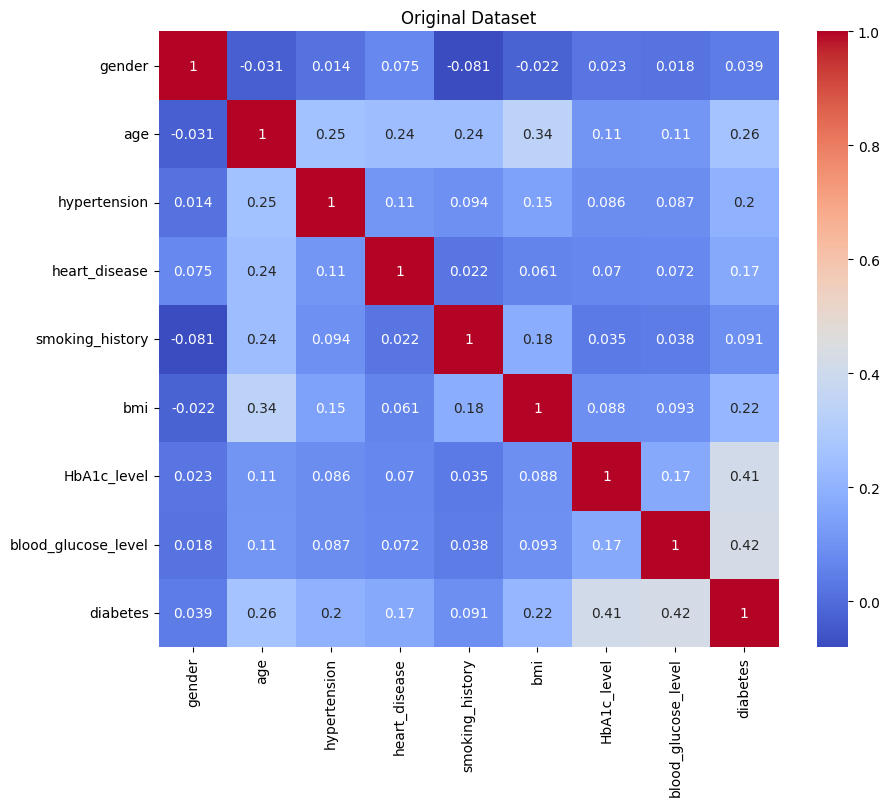

In [ ]:
#Compare Correlation Heatmaps
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.title("Original Dataset")

plt.show()

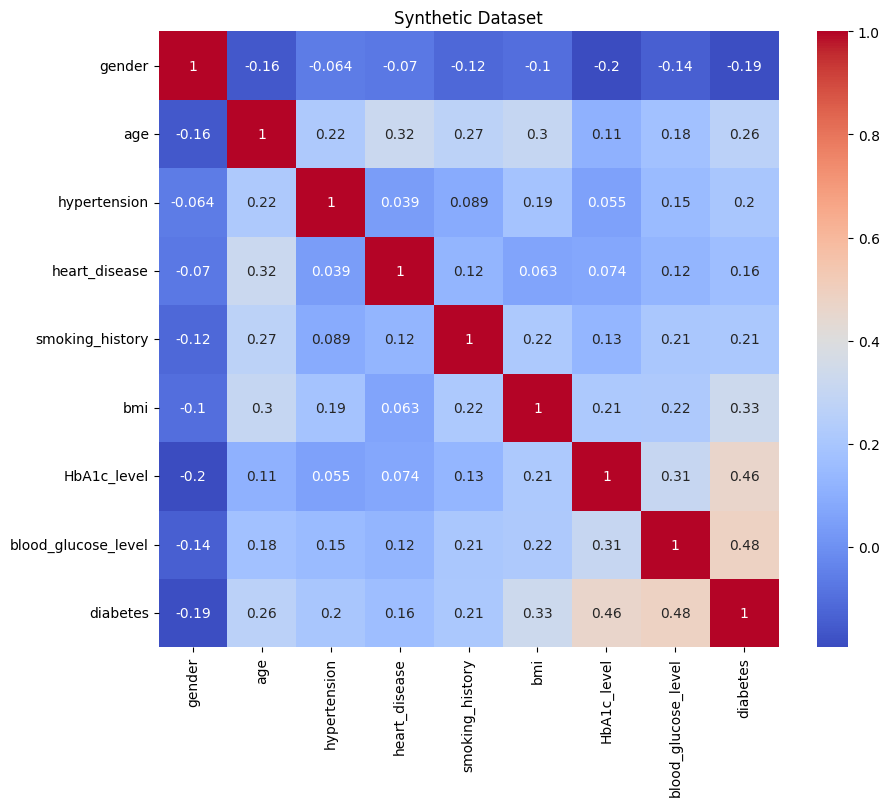

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(synthetic_data.corr(), annot=True, cmap="coolwarm")

plt.title("Synthetic Dataset")

plt.show()

In [ ]:
#Download Files
from google.colab import files

files.download("synthetic_patient_data.csv")

files.download("ctgan_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Model Training (Original vs Augmented Dataset)

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

import joblib

In [ ]:
#Load Original Dataset
original_data = pd.read_csv("clean_diabetes_dataset.csv")

original_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,4,-0.314947,0.994563,0.043554,0
1,0,0.543372,0,0,0,-0.000216,0.994563,-1.423096,0
2,1,-0.614096,0,0,4,-0.000216,0.155970,0.483549,0
3,0,-0.257952,0,0,1,-0.572051,-0.496269,0.410216,0
4,1,1.522768,1,1,1,-1.061141,-0.682623,0.410216,0


In [ ]:
#Load Synthetic Dataset
synthetic_data = pd.read_csv("synthetic_patient_data.csv")

synthetic_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,0.230297,0.0,0.0,1.0,0.005266,0.176323,-0.213080,0.0
1,1,0.172577,0.0,0.0,0.0,0.878554,0.997178,0.414633,0.0
2,1,1.084370,0.0,0.0,4.0,0.599700,-0.646472,0.453055,0.0
3,0,0.408555,0.0,0.0,3.0,0.497286,0.932128,0.506766,0.0
4,1,-0.335439,0.0,0.0,3.0,0.001070,-0.641309,0.039994,0.0


In [ ]:
#Check Dataset Shapes
print("Original Dataset Shape")
print(original_data.shape)

print()

print("Synthetic Dataset Shape")
print(synthetic_data.shape)

Original Dataset Shape
(96146, 9)

Synthetic Dataset Shape
(5000, 9)


In [ ]:
#Merge Both Datasets
augmented_data = pd.concat(
    [original_data, synthetic_data],
    ignore_index=True
)

augmented_data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0.0,1.0,4.0,-0.314947,0.994563,0.043554,0.0
1,0,0.543372,0.0,0.0,0.0,-0.000216,0.994563,-1.423096,0.0
2,1,-0.614096,0.0,0.0,4.0,-0.000216,0.155970,0.483549,0.0
3,0,-0.257952,0.0,0.0,1.0,-0.572051,-0.496269,0.410216,0.0
4,1,1.522768,1.0,1.0,1.0,-1.061141,-0.682623,0.410216,0.0


In [ ]:
#Check Augmented Dataset Shape
print("Augmented Dataset Shape")

print(augmented_data.shape)

Augmented Dataset Shape
(101146, 9)


In [ ]:
#Shuffle Dataset
augmented_data = augmented_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [ ]:
#Save Augmented Dataset
augmented_data.to_csv(
    "augmented_dataset.csv",
    index=False
)

In [ ]:
#Features & Target (Original Data)
X_original = original_data.drop("diabetes", axis=1)

y_original = original_data["diabetes"]

In [ ]:
#Train-Test Split
X_train_org, X_test_org, y_train_org, y_test_org = train_test_split(
    X_original,
    y_original,
    test_size=0.2,
    random_state=42,
    stratify=y_original
)

In [ ]:
#Train Random Forest (Original Dataset)
rf_original = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_original.fit(
    X_train_org,
    y_train_org
)

RandomForestClassifier(random_state=42)

In [ ]:
#Predict
y_pred_org = rf_original.predict(X_test_org)

y_prob_org = rf_original.predict_proba(X_test_org)[:,1]

In [ ]:
#Evaluation (Original Dataset)
print("Accuracy :", accuracy_score(y_test_org, y_pred_org))

print("Precision :", precision_score(y_test_org, y_pred_org))

print("Recall :", recall_score(y_test_org, y_pred_org))

print("F1 Score :", f1_score(y_test_org, y_pred_org))

print("ROC AUC :", roc_auc_score(y_test_org, y_prob_org))

Accuracy : 0.9694747789911596
Precision : 0.9489878542510122
Recall : 0.6910377358490566
F1 Score : 0.799727055612419
ROC AUC : 0.9579441915814234


In [ ]:
#Classification Report
print(classification_report(
    y_test_org,
    y_pred_org
))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17534
           1       0.95      0.69      0.80      1696

    accuracy                           0.97     19230
   macro avg       0.96      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



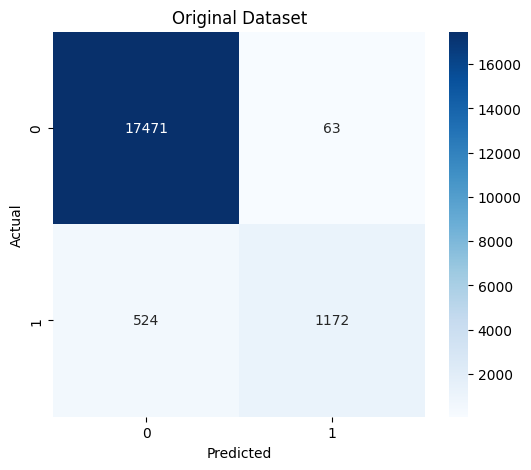

In [ ]:
#Confusion Matrix
cm = confusion_matrix(
    y_test_org,
    y_pred_org
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Original Dataset")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

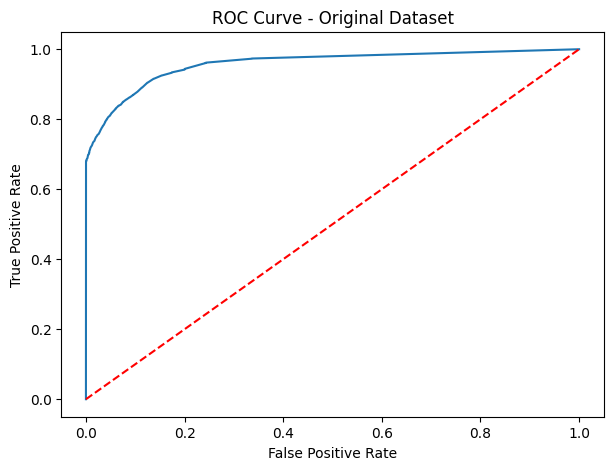

In [ ]:
#ROC Curve
fpr, tpr, threshold = roc_curve(
    y_test_org,
    y_prob_org
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Original Dataset")

plt.show()

In [ ]:
#Features & Target (Augmented Data)
X_aug = augmented_data.drop(
    "diabetes",
    axis=1
)

y_aug = augmented_data["diabetes"]

In [ ]:
# Remove rows with NaN values from y_aug and corresponding rows from X_aug
# Identify rows where 'diabetes' (y_aug) is not NaN
non_nan_mask = y_aug.notna()
X_aug = X_aug[non_nan_mask]
y_aug = y_aug[non_nan_mask]

#Train-Test Split
X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_aug,
    y_aug,
    test_size=0.2,
    random_state=42,
    stratify=y_aug
)

In [ ]:
#Train Random Forest
rf_augmented = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_augmented.fit(
    X_train_aug,
    y_train_aug
)

RandomForestClassifier(random_state=42)

In [ ]:
#Prediction
y_pred_aug = rf_augmented.predict(X_test_aug)

y_prob_aug = rf_augmented.predict_proba(X_test_aug)[:,1]

In [ ]:
#Evaluation
print("Accuracy :", accuracy_score(y_test_aug, y_pred_aug))

print("Precision :", precision_score(y_test_aug, y_pred_aug))

print("Recall :", recall_score(y_test_aug, y_pred_aug))

print("F1 Score :", f1_score(y_test_aug, y_pred_aug))

print("ROC AUC :", roc_auc_score(y_test_aug, y_prob_aug))

Accuracy : 0.9676860649247823
Precision : 0.9308624376336422
Recall : 0.7013963480128894
F1 Score : 0.8
ROC AUC : 0.9613192695416887


In [ ]:
#Classification Report
print(classification_report(
    y_test_aug,
    y_pred_aug
))

              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     18346
         1.0       0.93      0.70      0.80      1862

    accuracy                           0.97     20208
   macro avg       0.95      0.85      0.89     20208
weighted avg       0.97      0.97      0.97     20208



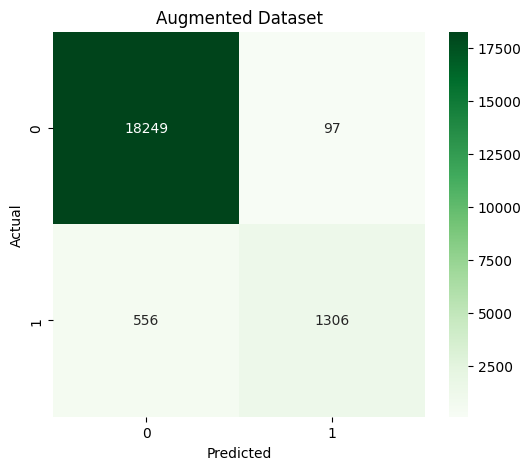

In [ ]:
#Confusion Matrix
cm = confusion_matrix(
    y_test_aug,
    y_pred_aug
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Augmented Dataset")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

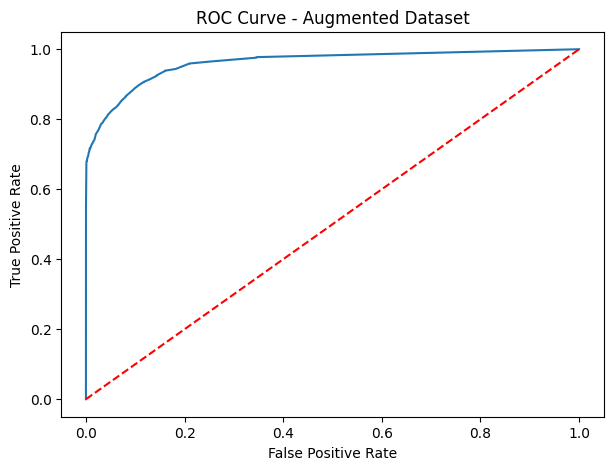

In [ ]:
#ROC Curve
fpr, tpr, threshold = roc_curve(
    y_test_aug,
    y_prob_aug
)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Augmented Dataset")

plt.show()

In [ ]:
#Compare Results
results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC AUC"
    ],

    "Original":[
        accuracy_score(y_test_org,y_pred_org),
        precision_score(y_test_org,y_pred_org),
        recall_score(y_test_org,y_pred_org),
        f1_score(y_test_org,y_pred_org),
        roc_auc_score(y_test_org,y_prob_org)
    ],

    "Augmented":[
        accuracy_score(y_test_aug,y_pred_aug),
        precision_score(y_test_aug,y_pred_aug),
        recall_score(y_test_aug,y_pred_aug),
        f1_score(y_test_aug,y_pred_aug),
        roc_auc_score(y_test_aug,y_prob_aug)
    ]

})

results

,Metric,Original,Augmented
0,Accuracy,0.969475,0.967686
1,Precision,0.948988,0.930862
2,Recall,0.691038,0.701396
3,F1 Score,0.799727,0.800000
4,ROC AUC,0.957944,0.961319


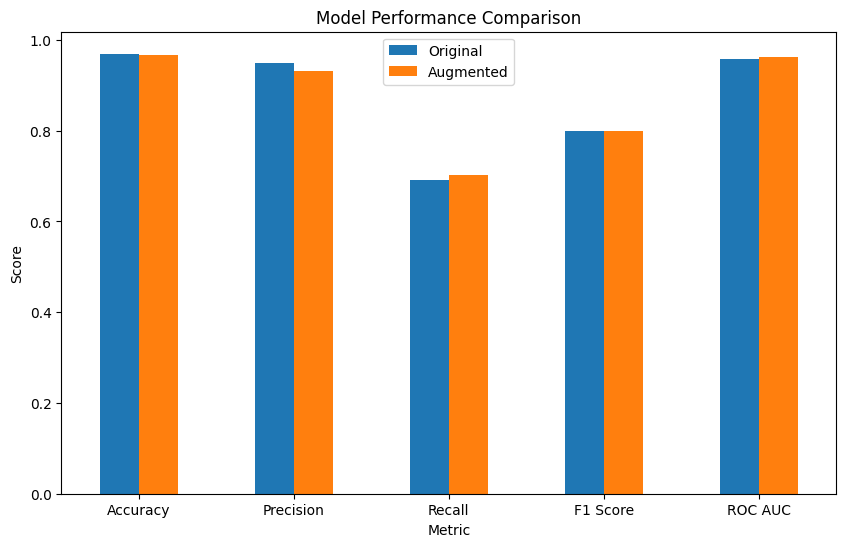

In [ ]:
#Plot Comparison
results.set_index("Metric").plot(kind="bar",figsize=(10,6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [ ]:
#Feature Importance
importance = pd.DataFrame({"Feature":X_aug.columns,"Importance":rf_augmented.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)

importance

,Feature,Importance
6,HbA1c_level,0.385839
7,blood_glucose_level,0.324316
5,bmi,0.122300
1,age,0.108311
4,smoking_history,0.027487
2,hypertension,0.013761
3,heart_disease,0.010474
0,gender,0.007511


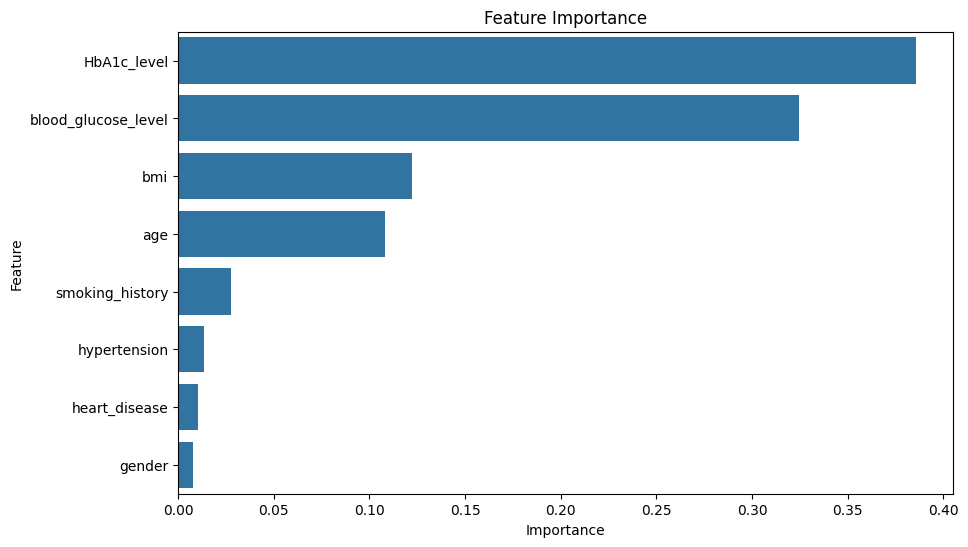

In [ ]:
#Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Feature Importance")
plt.show()

In [ ]:
#Save Model
joblib.dump(rf_augmented,"random_forest.pkl")

['random_forest.pkl']

In [ ]:
#Download Files
from google.colab import files

files.download("random_forest.pkl")

files.download("augmented_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#Evaluation & Visualization

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

import joblib

In [ ]:
#Load Datasets
original = pd.read_csv("clean_diabetes_dataset.csv")

synthetic = pd.read_csv("synthetic_patient_data.csv")

augmented = pd.read_csv("augmented_dataset.csv")

In [ ]:
#Check Shapes
print("Original :", original.shape)

print("Synthetic :", synthetic.shape)

print("Augmented :", augmented.shape)

Original : (96146, 9)
Synthetic : (5000, 9)
Augmented : (101146, 9)


In [ ]:
#Display First Five Rows
print("Original Dataset")
display(original.head())
print("Synthetic Dataset")
display(synthetic.head())

Original Dataset


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,4,-0.314947,0.994563,0.043554,0
1,0,0.543372,0,0,0,-0.000216,0.994563,-1.423096,0
2,1,-0.614096,0,0,4,-0.000216,0.155970,0.483549,0
3,0,-0.257952,0,0,1,-0.572051,-0.496269,0.410216,0
4,1,1.522768,1,1,1,-1.061141,-0.682623,0.410216,0


Synthetic Dataset


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,0.230297,0.0,0.0,1.0,0.005266,0.176323,-0.213080,0.0
1,1,0.172577,0.0,0.0,0.0,0.878554,0.997178,0.414633,0.0
2,1,1.084370,0.0,0.0,4.0,0.599700,-0.646472,0.453055,0.0
3,0,0.408555,0.0,0.0,3.0,0.497286,0.932128,0.506766,0.0
4,1,-0.335439,0.0,0.0,3.0,0.001070,-0.641309,0.039994,0.0


In [ ]:
#Statistical Comparison
comparison = pd.DataFrame({"Original Mean":original.mean(),"Synthetic Mean":synthetic.mean()})
comparison

,Original Mean,Synthetic Mean
gender,4.160652e-01,0.404000
age,3.386211e-16,0.250259
hypertension,7.760073e-02,0.112972
heart_disease,4.080253e-02,0.103962
smoking_history,2.231159e+00,2.491422
bmi,-3.776416e-16,0.087463
HbA1c_level,2.391484e-16,0.178786
blood_glucose_level,-7.419808e-17,0.068791
diabetes,8.822000e-02,0.169121


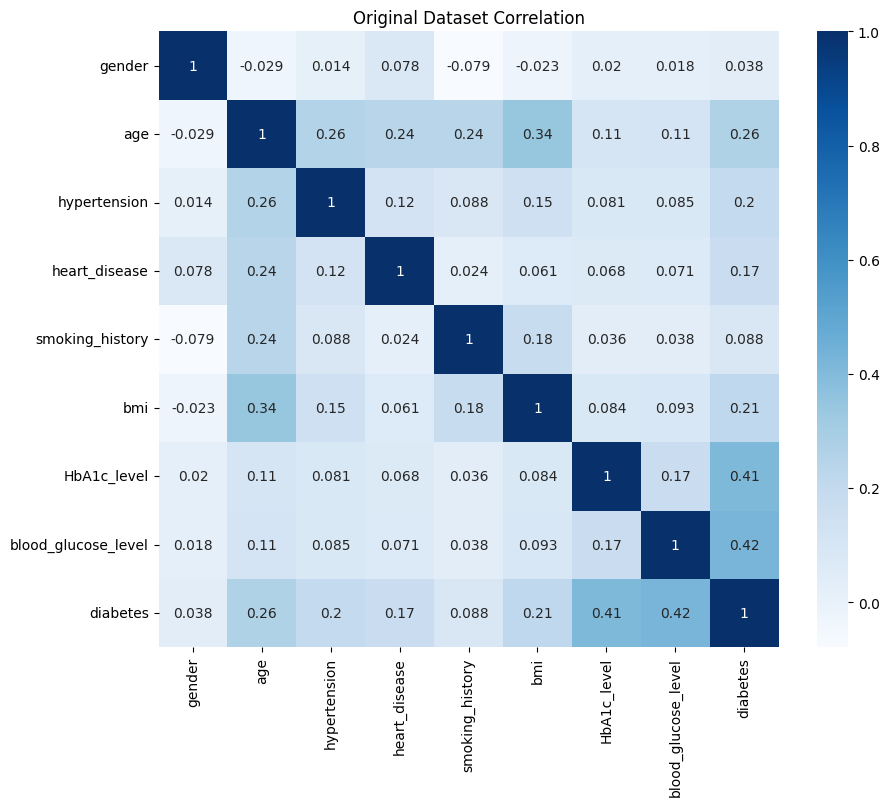

In [ ]:
#Correlation Heatmap (Original)
plt.figure(figsize=(10,8))
sns.heatmap(original.corr(),annot=True,cmap="Blues")
plt.title("Original Dataset Correlation")
plt.savefig("original_heatmap.png")
plt.show()

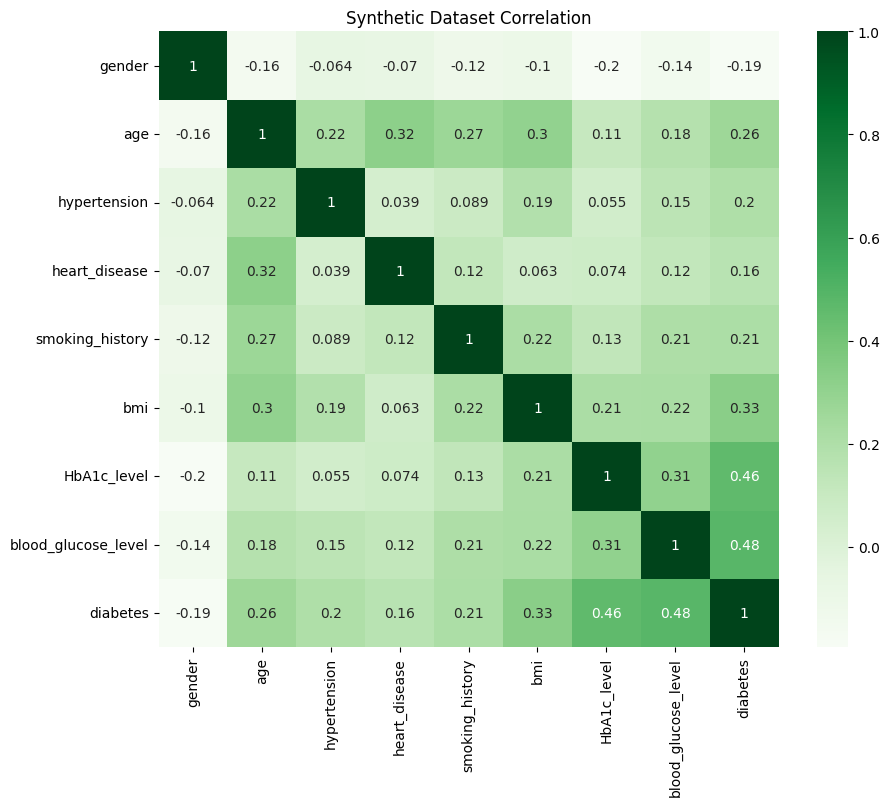

In [ ]:
#Correlation Heatmap (Synthetic)
plt.figure(figsize=(10,8))
sns.heatmap(synthetic.corr(),annot=True,cmap="Greens")
plt.title("Synthetic Dataset Correlation")
plt.savefig("synthetic_heatmap.png")
plt.show()

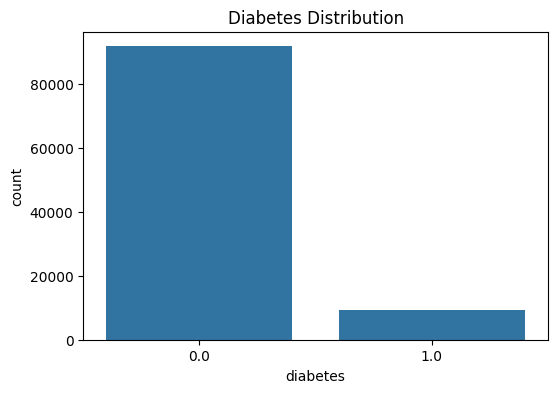

In [ ]:
#Diabetes Distribution
plt.figure(figsize=(6,4))

sns.countplot(x="diabetes",data=augmented)
plt.title("Diabetes Distribution")
plt.savefig("diabetes_distribution.png")
plt.show()

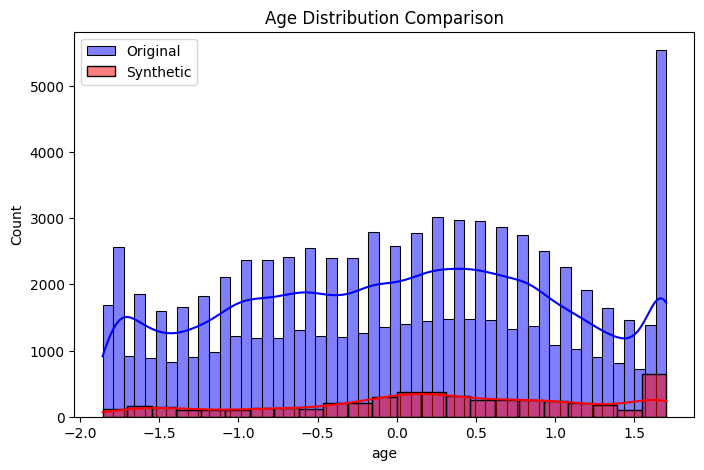

In [ ]:
#Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(original["age"],color="blue",label="Original",kde=True)
sns.histplot(synthetic["age"],color="red",label="Synthetic",kde=True)
plt.legend()
plt.title("Age Distribution Comparison")
plt.savefig("age_distribution.png")
plt.show()

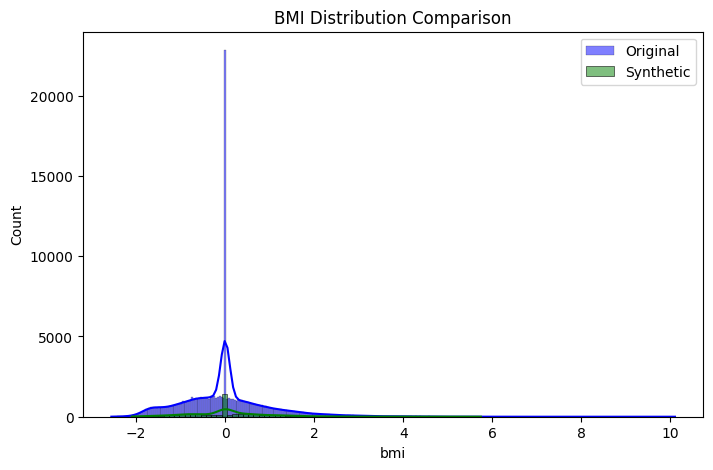

In [ ]:
#BMI Distribution
plt.figure(figsize=(8,5))

sns.histplot(original["bmi"],color="blue",label="Original",kde=True)
sns.histplot(synthetic["bmi"],color="green",label="Synthetic",kde=True)
plt.legend()
plt.title("BMI Distribution Comparison")
plt.savefig("bmi_distribution.png")
plt.show()

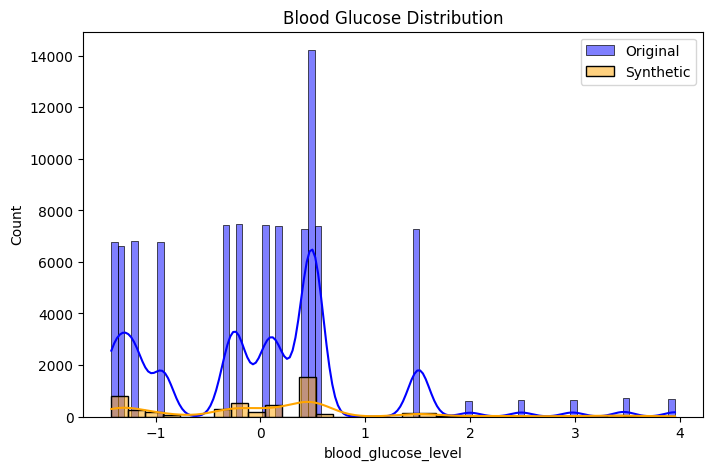

In [ ]:
#Blood Glucose Distribution
plt.figure(figsize=(8,5))

sns.histplot(original["blood_glucose_level"],color="blue",label="Original",kde=True)
sns.histplot(synthetic["blood_glucose_level"],color="orange",label="Synthetic",kde=True)
plt.legend()
plt.title("Blood Glucose Distribution")
plt.savefig("blood_glucose_distribution.png")
plt.show()

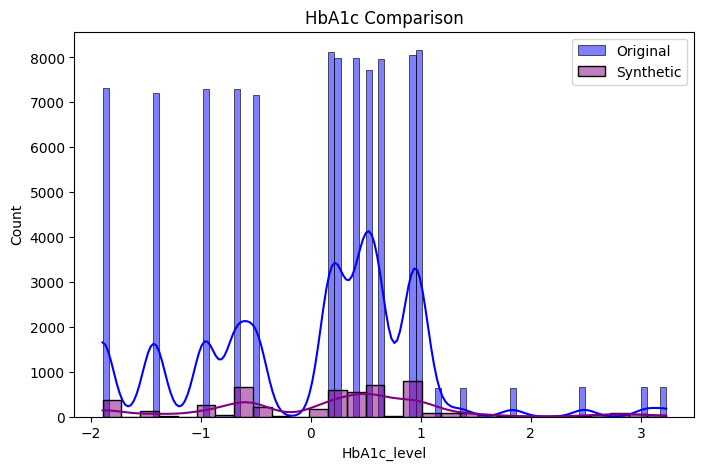

In [ ]:
#HbA1c Distribution
plt.figure(figsize=(8,5))

sns.histplot(original["HbA1c_level"],color="blue",label="Original",kde=True)
sns.histplot(synthetic["HbA1c_level"],color="purple",label="Synthetic",kde=True)
plt.legend()
plt.title("HbA1c Comparison")
plt.savefig("hba1c_distribution.png")
plt.show()

In [ ]:
#PCA Visualization
pca = PCA(n_components=2)

# Drop rows with NaN values before applying PCA
original_cleaned = original.dropna()
synthetic_cleaned = synthetic.dropna()

original_pca = pca.fit_transform(original_cleaned)

synthetic_pca = pca.transform(synthetic_cleaned)

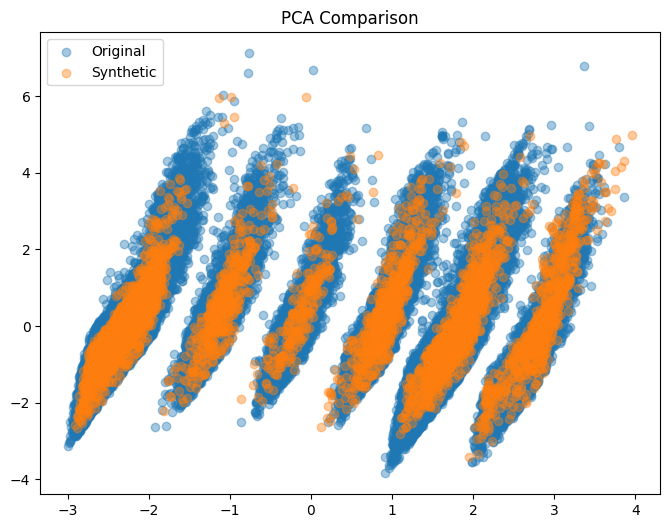

In [ ]:
#Plot PCA
plt.figure(figsize=(8,6))

plt.scatter(original_pca[:,0],original_pca[:,1],alpha=0.4,label="Original")
plt.scatter(synthetic_pca[:,0],synthetic_pca[:,1],alpha=0.4,label="Synthetic")
plt.legend()
plt.title("PCA Comparison")
plt.savefig("PCA_plot.png")
plt.show()

In [ ]:
#t-SNE Visualization
# Drop NaN values from synthetic data before sampling
synthetic_cleaned = synthetic.dropna()
combined = pd.concat([original.sample(500, random_state=42),synthetic_cleaned.sample(500, random_state=42)])
labels = ["Original"]*500 + ["Synthetic"]*500
tsne = TSNE(n_components=2,random_state=42)
tsne_result = tsne.fit_transform(combined)

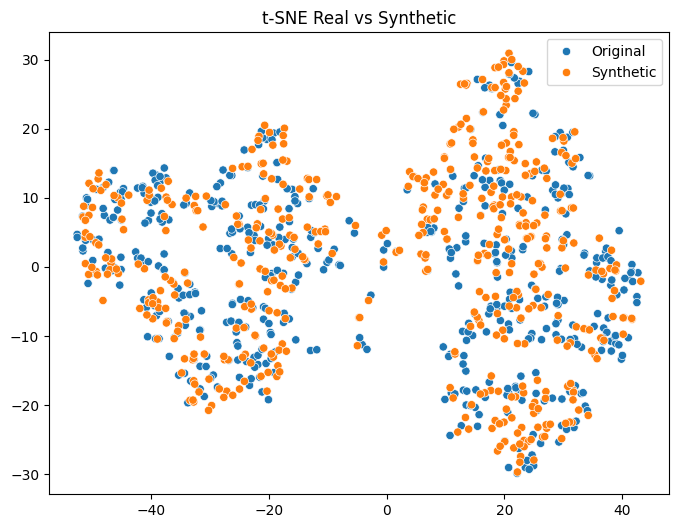

In [ ]:
#Plot t-SNE
plt.figure(figsize=(8,6))
sns.scatterplot(x=tsne_result[:,0],y=tsne_result[:,1],hue=labels)
plt.title("t-SNE Real vs Synthetic")
plt.savefig("tsne_plot.png")
plt.show()

In [ ]:
#Load Random Forest Model
model = joblib.load("random_forest.pkl")

In [ ]:
#Feature Importance
importance = pd.DataFrame({"Feature":augmented.drop("diabetes",axis=1).columns,"Importance":model.feature_importances_})
importance = importance.sort_values(by="Importance",ascending=False)
importance

,Feature,Importance
6,HbA1c_level,0.385839
7,blood_glucose_level,0.324316
5,bmi,0.122300
1,age,0.108311
4,smoking_history,0.027487
2,hypertension,0.013761
3,heart_disease,0.010474
0,gender,0.007511


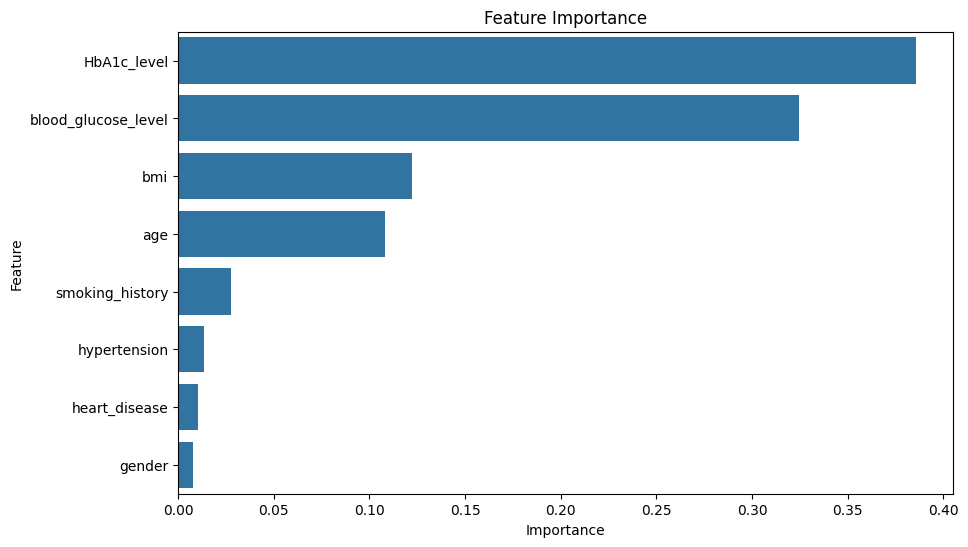

In [ ]:
#Plot Feature Importance
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Feature Importance")
plt.savefig("feature_importance.png")
plt.show()

In [ ]:
#Save Evaluation Summary
summary = pd.DataFrame({"Dataset":["Original","Synthetic","Augmented"],"Rows":[len(original),len(synthetic),len(augmented)],"Columns":[original.shape[1],synthetic.shape[1],augmented.shape[1]]})
summary


,Dataset,Rows,Columns
0,Original,96146,9
1,Synthetic,5000,9
2,Augmented,101146,9


In [ ]:
#Save Summary
summary.to_csv("evaluation_summary.csv",index=False)

In [ ]:
#Download All Graphs
from google.colab import files

files.download("original_heatmap.png")

files.download("synthetic_heatmap.png")

files.download("diabetes_distribution.png")

files.download("age_distribution.png")

files.download("bmi_distribution.png")

files.download("blood_glucose_distribution.png")

files.download("hba1c_distribution.png")

files.download("PCA_plot.png")

files.download("tsne_plot.png")

files.download("feature_importance.png")

files.download("evaluation_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Conclusion

This project successfully demonstrated the application of Generative AI for generating synthetic medical diagnosis records in the healthcare domain.

The project began with exploratory data analysis and preprocessing of a diabetes healthcare dataset. The dataset was cleaned, duplicate records were removed, and categorical features were converted into numerical representations.

A CTGAN (Conditional Tabular Generative Adversarial Network) model was then trained on the cleaned healthcare dataset. The trained model successfully generated synthetic patient records that followed similar patterns and distributions to the original dataset.

The quality of the generated synthetic data was evaluated using statistical analysis, distribution comparisons, correlation heatmaps, and dimensionality reduction techniques such as PCA. The synthetic data was then combined with the original dataset to create an augmented dataset.

A Random Forest classification model was trained using both the original and augmented datasets. The model performance was evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC, and a Confusion Matrix.

Overall, this project demonstrates that CTGAN can be used as a Generative AI technique for generating synthetic tabular healthcare data and supporting machine learning experimentation and data augmentation.

Synthetic healthcare data can be useful for research, model development, testing, and educational purposes. However, it should not be directly used for clinical diagnosis or patient treatment without proper clinical validation, privacy assessment, ethical review, and regulatory approval.

This project provided practical experience in Generative AI, synthetic data generation, healthcare data analysis, machine learning, model evaluation, and end-to-end AI/ML project development.